# Scalable cases example

In this example, we will the graphs presented in our article in .........

In [1]:
import logging
import os

import networkx as nx
import pandas as pd

from pici.causal_model import CausalModel
from pici.utils._enum import DataExamplesPaths

THIS_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(THIS_DIR, ".."))
import sys
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

/home/lawand/.cache/pypoetry/virtualenvs/pici-fDrhQdDz-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Defining the model

In [2]:
n1_m2_input = "X -> A1, X -> B1, X -> B2, B1 -> A1, B2 -> A1, A1 -> Y, U1 -> X, U1 -> A1, U2 -> B1, U2 -> B2, U2 -> Y"
n1_m2_cardinalities = {"X": 2, "Y": 2, "B1": 2, "B2": 2, "A1": 2, "U1": 0, "U2": 0}

n1_m2_unobs = ["U1", "U2"]
n1_m2_target = "Y"
n1_m2_target_value = 1
n1_m2_intervention = "X"
n1_m2_intervention_value = 1
n1_m2_csv_path = DataExamplesPaths.CSV_N1M2.value
n1_m2_df = pd.read_csv(os.path.join(PROJECT_ROOT, n1_m2_csv_path))

n1_m2_model = CausalModel(
    data=n1_m2_df,
    edges=n1_m2_input,
    custom_cardinalities=n1_m2_cardinalities,
    unobservables_labels=n1_m2_unobs,
    interventions=(n1_m2_intervention, n1_m2_intervention_value),
    target=(n1_m2_target, n1_m2_target_value),
)

## Visualizing the graph

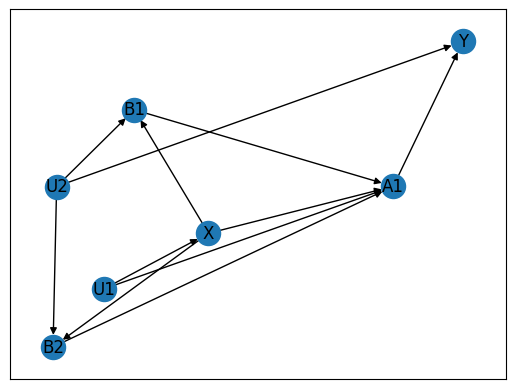

In [3]:
nx.draw_networkx(n1_m2_model.graph.DAG)

## Generating an image to save

In [4]:
n1_m2_model.generate_graph_image("N1_M2.png")

## Checking d-separation

In [5]:
print(
    f"Is A1 d-separated from node B1 given node B2? {n1_m2_model.are_d_separated_in_intervened_graph(['A1'], ['B1'], ['B2'])}"
)

Is A1 d-separated from node B1 given node B2? False


## Calculating the interventions

In [6]:
lower, upper = n1_m2_model.intervention_query()
print(
    f"{lower} <= P({n1_m2_target}={n1_m2_target_value}|do({n1_m2_intervention}={n1_m2_intervention_value})) <= {upper}"
)

Restricted license - for non-production use only - expires 2026-11-23


INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23
INFO:pici.intervention_inference_algorithm.linear_programming.optimizers:Minimal solution found! Minimal Query: 0.08757281136705905
INFO:pici.intervention_inference_algorithm.linear_programming.optimizers:Maximal solution found! Maximal Query: 0.5560331879942401
INFO:pici.intervention_inference_algorithm.linear_programming.opt_problem_builder:Causal query: P(Y=1|do(X=1))
INFO:pici.intervention_inference_algorithm.linear_programming.opt_problem_builder:Bounds: 0.08757281136705905 <= P <= 0.5560331879942401


0.08757281136705905 <= P(Y=1|do(X=1)) <= 0.5560331879942401
